In [ ]:
import argparse
import json
import sys
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import pandas as pd

from motion_estimator import MotionEstimator

def load_config(config_path: Path | None) -> dict:
	default = Path("test_config_altitude.json")
	if config_path and config_path.exists():
		with open(config_path, "r") as f:
			return json.load(f)
	if default.exists():
		with open(default, "r") as f:
			return json.load(f)
	return {"test_sequence": []}


def load_dataframe(csv_path: Path) -> pd.DataFrame:
	df = pd.read_csv(csv_path)
	required = ["timestamp", "accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]
	missing = [c for c in required if c not in df.columns]
	if missing:
		raise ValueError(f"Missing columns in {csv_path}: {missing}")
	for c in required[1:]:
		df[c] = pd.to_numeric(df[c], errors="coerce")
	df = df.dropna(subset=required)
	return df


def edn_to_ned(df: pd.DataFrame) -> pd.DataFrame:
	# Copy to avoid modifying caller
	df = df.copy()
	# Accelerometer
	df["accel_x"], df["accel_y"], df["accel_z"] = (
		df["accel_z"],
		df["accel_x"],
		-df["accel_y"],
	)
	# Gyroscope
	df["gyro_x"], df["gyro_y"], df["gyro_z"] = (
		df["gyro_z"],
		df["gyro_x"],
		-df["gyro_y"],
	)
	return df


def regularize_timestamps(ts: np.ndarray, fs: float) -> np.ndarray:
	current = float(ts[0])
	updated: list[float] = []
	for i in range(1, len(ts)):
		if ts[i] + 10 < ts[i - 1]:
			current = float(ts[i])
		updated.append(current)
		current += 1.0 / fs
	updated.append(current)
	return np.array(updated, dtype=float)


def segment_by_gaps(df: pd.DataFrame, gap_s: float = 5.0) -> list[tuple[int, int]]:
	ts = df["timestamp"].to_numpy()
	gaps = np.where(np.abs(np.diff(ts)) > gap_s)[0]
	bounds: list[tuple[int, int]] = []
	start = 0
	for gi in gaps:
		bounds.append((start, gi + 1))
		start = gi + 1
	bounds.append((start, len(df)))
	return bounds


def map_segments_to_config(df: pd.DataFrame, config: dict) -> list[dict]:
	bounds = segment_by_gaps(df)
	seq = config.get("test_sequence", [])
	segments: list[dict] = []
	for i, (s, e) in enumerate(bounds):
		meta = seq[i] if i < len(seq) else {"test_id": i}
		segments.append({
			"test_id": int(meta.get("test_id", i)),
			"data": df.iloc[s:e].reset_index(drop=True),
			"config": meta,
			"start_idx": s,
			"end_idx": e,
		})
	return segments
def process_segment_with_estimator(segment_data: pd.DataFrame, estimator: MotionEstimator) -> pd.DataFrame:
    """Process a segment through the MotionEstimator"""
    results = []
    
    for i, row in segment_data.iterrows():
        # Convert from mg to g for consistency with MotionEstimator
        accel_raw = [row["accel_x"], row["accel_y"], row["accel_z"]]  # Already in mg
        gyro_raw = [row["gyro_x"], row["gyro_y"], row["gyro_z"]]      # Already in dps
        
        output = estimator.update(accel_raw, gyro_raw, row["timestamp"])
        output["sample_idx"] = i
        results.append(output)
    
    return pd.DataFrame(results)

def detect_angle_changes(segment_df: pd.DataFrame, config: dict, fs: float = 104.0) -> dict:
    """Detect angle changes in processed segment data"""
    # Get stable regions (first and last 20% of data)
    n_samples = len(segment_df)
    stable_start = int(n_samples * 0.1)
    stable_end = int(n_samples * 0.9)
    
    # Calculate mean angles in stable regions
    start_angles = segment_df.iloc[:stable_start][["pitch_deg", "yaw_deg", "roll_deg"]].mean()
    end_angles = segment_df.iloc[stable_end:][["pitch_deg", "yaw_deg", "roll_deg"]].mean()
    
    # Calculate changes
    detected_changes = {
        "theta_change": end_angles["pitch_deg"] - start_angles["pitch_deg"],
        "phi_change": end_angles["yaw_deg"] - start_angles["yaw_deg"],
        "psi_change": end_angles["roll_deg"] - start_angles["roll_deg"],
        "max_dps": segment_df[["pitch_deg", "yaw_deg", "roll_deg"]].diff().abs().max().max() * fs
    }

    return detected_changes

def analyze_segment_errors(segment: dict, estimator: MotionEstimator, fs: float = 104) -> dict:
    """Analyze errors for a single segment"""
    test_config = segment["config"]

    processed_df = process_segment_with_estimator(segment["data"], estimator)
    detected = detect_angle_changes(processed_df, test_config, fs)

    detection_threshold = 2.0  # degrees
    result = {
        "test_id": segment["test_id"],
        "description": test_config.get("description", ""),
        "max_dps": detected["max_dps"],
        "expected_detectable": test_config.get("expected_detectable", True),
        "processed_data": processed_df
    }

    if test_config.get("power_state", "off") != "on":
        return None

    # θ (altitude)
    if "theta_change" in test_config:
        expected_theta = test_config["theta_change"]
        theta_error = abs(detected["theta_change"] - expected_theta)
        theta_detected = theta_error < detection_threshold if expected_theta != 0 else theta_error < 0.5
        result.update({
            "expected_theta": expected_theta,
            "detected_theta": detected["theta_change"],
            "theta_error": theta_error,
            "theta_detected": theta_detected,
        })

    # φ (azimuth)
    if "phi_change" in test_config:
        expected_phi = test_config["phi_change"]
        phi_error = abs(detected["phi_change"] - expected_phi)
        phi_detected = phi_error < detection_threshold if expected_phi != 0 else phi_error < 0.5
        result.update({
            "expected_phi": expected_phi,
            "detected_phi": detected["phi_change"],
            "phi_error": phi_error,
            "phi_detected": phi_detected,
        })

    return result

    
def generate_confusion_matrix(results_df: pd.DataFrame) -> dict:
    """Generate confusion matrices only for the angles present."""
    matrices = {}

    if "expected_theta" in results_df.columns:
        theta_tp = ((results_df["expected_theta"] != 0) & results_df["theta_detected"]).sum()
        theta_fp = ((results_df["expected_theta"] == 0) & results_df["theta_detected"]).sum()
        theta_tn = ((results_df["expected_theta"] == 0) & ~results_df["theta_detected"]).sum()
        theta_fn = ((results_df["expected_theta"] != 0) & ~results_df["theta_detected"]).sum()
        matrices["theta"] = np.array([[theta_tp, theta_fp], [theta_fn, theta_tn]])

    if "expected_phi" in results_df.columns:
        phi_tp = ((results_df["expected_phi"] != 0) & results_df["phi_detected"]).sum()
        phi_fp = ((results_df["expected_phi"] == 0) & results_df["phi_detected"]).sum()
        phi_tn = ((results_df["expected_phi"] == 0) & ~results_df["phi_detected"]).sum()
        phi_fn = ((results_df["expected_phi"] != 0) & ~results_df["phi_detected"]).sum()
        matrices["phi"] = np.array([[phi_tp, phi_fp], [phi_fn, phi_tn]])

    return matrices


def create_error_heatmap(results_df: pd.DataFrame) -> tuple:
    """Create error heatmap vs angle magnitude and DPS"""
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Prepare data for heatmap
    angle_bins = [0, 1, 2, 3, 5, 10, 15, 20, 30, 45]
    dps_bins = [0, 5, 10, 20, 50, 100, 200]

    
    # Create binned columns
    results_df["angle_bin"] = pd.cut(
        results_df[["expected_theta", "expected_phi"]].abs().max(axis=1),
        bins=angle_bins,
        labels=[f"{angle_bins[i]}-{angle_bins[i+1]}" for i in range(len(angle_bins)-1)]
    )
    
    results_df["dps_bin"] = pd.cut(
        results_df["max_dps"],
        bins=dps_bins,
        labels=[f"{dps_bins[i]}-{dps_bins[i+1]}" for i in range(len(dps_bins)-1)]
    )
    

    errors = []

    if "theta_error" in results_df.columns:
        errors.append("theta_error")
    if "phi_error" in results_df.columns:
        errors.append("phi_error")
    if not errors:
        return pd.DataFrame()  # nothing to plot

    error_matrix = results_df.pivot_table(
        values=errors,
        index="angle_bin",
        columns="dps_bin",
        aggfunc="mean"
    )
    return error_matrix

def plot_analysis_results(results_df: pd.DataFrame, output_prefix: str):
    """Create comprehensive visualization of results.

    This function is robust to missing columns: it will only plot the
    panels for which data exists (theta, phi, max_dps). If a panel has
    no data, a short message is drawn instead of raising an error.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Quick guard
    if results_df is None or results_df.empty:
        print("No results to plot.")
        return

    # Column availability
    has_expected_theta = "expected_theta" in results_df.columns
    has_expected_phi = "expected_phi" in results_df.columns
    has_theta_error = "theta_error" in results_df.columns
    has_phi_error = "phi_error" in results_df.columns
    has_theta_detected = "theta_detected" in results_df.columns
    has_phi_detected = "phi_detected" in results_df.columns
    has_max_dps = "max_dps" in results_df.columns

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # -----------------------
    # 1) Error vs Angle Magnitude
    ax = axes[0, 0]
    plotted = False
    if has_expected_theta and has_theta_error:
        ax.scatter(results_df["expected_theta"].abs(), results_df["theta_error"],
                   alpha=0.6, label="Altitude")
        plotted = True
    if has_expected_phi and has_phi_error:
        ax.scatter(results_df["expected_phi"].abs(), results_df["phi_error"],
                   alpha=0.6, label="Azimuth")
        plotted = True
    if not plotted:
        ax.text(0.5, 0.5, "No angle-error data available", ha="center", va="center")
    ax.set_xlabel("Expected Angle (deg)")
    ax.set_ylabel("Error (deg)")
    ax.set_title("Error vs Angle Magnitude")
    if plotted:
        ax.legend()
    ax.grid(True, alpha=0.3)

    # -----------------------
    # 2) Error vs DPS
    ax = axes[0, 1]
    plotted = False
    if has_max_dps and has_theta_error:
        ax.scatter(results_df["max_dps"], results_df["theta_error"],
                   alpha=0.6, label="Altitude")
        plotted = True
    if has_max_dps and has_phi_error:
        ax.scatter(results_df["max_dps"], results_df["phi_error"],
                   alpha=0.6, label="Azimuth")
        plotted = True
    if not plotted:
        ax.text(0.5, 0.5, "No DPS vs error data available", ha="center", va="center")
    ax.set_xlabel("Max DPS")
    ax.set_ylabel("Error (deg)")
    ax.set_title("Error vs Angular Velocity")
    if plotted:
        ax.legend()
    ax.grid(True, alpha=0.3)

    # -----------------------
    # 3) Detection Success Rate (bar)
    ax = axes[0, 2]
    detection_series = {}
    if has_theta_detected:
        td = results_df["theta_detected"].astype(bool)
        detection_series["Altitude"] = [int(td.sum()), int((~td).sum())]
    if has_phi_detected:
        pdv = results_df["phi_detected"].astype(bool)
        detection_series["Azimuth"] = [int(pdv.sum()), int((~pdv).sum())]

    if detection_series:
        detection_data = pd.DataFrame(detection_series, index=["Detected", "Missed"])
        detection_data.plot(kind="bar", ax=ax)
    else:
        ax.text(0.5, 0.5, "No detection data available", ha="center", va="center")
    ax.set_title("Detection Success Rate")
    ax.set_ylabel("Count")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    # -----------------------
    # 4) Confusion Matrix - Altitude
    cm = generate_confusion_matrix(results_df)
    ax = axes[1, 0]
    if isinstance(cm, dict) and "theta" in cm:
        sns.heatmap(cm["theta"], annot=True, fmt="d", ax=ax, cmap="Blues", cbar=True)
    else:
        ax.text(0.5, 0.5, "No altitude confusion matrix", ha="center", va="center")
    ax.set_title("Altitude Detection Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    # -----------------------
    # 5) Confusion Matrix - Azimuth
    ax = axes[1, 1]
    if isinstance(cm, dict) and "phi" in cm:
        sns.heatmap(cm["phi"], annot=True, fmt="d", ax=ax, cmap="Greens", cbar=True)
    else:
        ax.text(0.5, 0.5, "No azimuth confusion matrix", ha="center", va="center")
    ax.set_title("Azimuth Detection Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    # -----------------------
    # 6) Error Distribution
    ax = axes[1, 2]
    plotted = False
    if has_theta_error:
        ax.hist(results_df["theta_error"].dropna(), bins=20, alpha=0.5, label="Altitude")
        plotted = True
    if has_phi_error:
        ax.hist(results_df["phi_error"].dropna(), bins=20, alpha=0.5, label="Azimuth")
        plotted = True
    if not plotted:
        ax.text(0.5, 0.5, "No error distribution data", ha="center", va="center")
    ax.set_xlabel("Error (deg)")
    ax.set_ylabel("Frequency")
    ax.set_title("Error Distribution")
    if plotted:
        ax.legend()

    plt.tight_layout()
    plt.savefig(f"{output_prefix}_analysis.png", dpi=150)
    plt.show()

    # -----------------------
    # Error heatmap (angle magnitude vs DPS) — call safely
    try:
        error_matrix = create_error_heatmap(results_df)
        if hasattr(error_matrix, "empty") and not error_matrix.empty:
            fig, ax = plt.subplots(1, 1, figsize=(10, 6))
            sns.heatmap(error_matrix, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
            ax.set_title("Error Heatmap: Angle vs DPS")
            plt.savefig(f"{output_prefix}_heatmap.png", dpi=150)
            plt.show()
        else:
            print("Sparse or no data for error heatmap — skipped.")
    except Exception as exc:
        # If the heatmap function still assumes columns that don't exist, don't crash whole plotting
        print(f"Skipping error heatmap due to: {exc}")


def generate_analysis_report(results_df: pd.DataFrame, output_prefix: str):
    """Generate comprehensive analysis report"""

    # Save detailed results to CSV
    results_df.to_csv(f"{output_prefix}_results.csv", index=False)
    print(f"\nDetailed results saved to {output_prefix}_results.csv")

    summary = {"Total Tests": len(results_df)}

    # Add altitude stats only if theta columns exist
    if "theta_error" in results_df.columns:
        summary.update({
            "Altitude Mean Error": results_df["theta_error"].mean(),
            "Altitude Std Error": results_df["theta_error"].std(),
            "Altitude Max Error": results_df["theta_error"].max(),
        })

    # Add azimuth stats only if phi columns exist
    if "phi_error" in results_df.columns:
        summary.update({
            "Azimuth Mean Error": results_df["phi_error"].mean(),
            "Azimuth Std Error": results_df["phi_error"].std(),
            "Azimuth Max Error": results_df["phi_error"].max(),
        })

    # Detection Rate: combine available detections
    detection_cols = []
    if "theta_detected" in results_df.columns:
        detection_cols.append(results_df["theta_detected"])
    if "phi_detected" in results_df.columns:
        detection_cols.append(results_df["phi_detected"])

    if detection_cols:
        detection_any = pd.concat(detection_cols, axis=1).any(axis=1)
        summary["Detection Rate"] = detection_any.mean() * 100

        summary["False Positive Rate"] = (
            (results_df.get("expected_detectable", True) == False) & detection_any
        ).mean() * 100
    else:
        summary["Detection Rate"] = 0.0
        summary["False Positive Rate"] = 0.0

    # Print summary
    print("\n" + "=" * 60)
    print("ANALYSIS SUMMARY")
    print("=" * 60)
    for key, value in summary.items():
        if "Error" in key:
            print(f"{key:<25}: {value:>8.3f} deg")
        elif "Rate" in key:
            print(f"{key:<25}: {value:>8.1f} %")
        else:
            print(f"{key:<25}: {value:>8}")

    # Reliability ranges + plots
    reliability_ranges = determine_reliability_ranges(results_df)

    print("\n" + "=" * 60)
    print("RELIABILITY RANGES")
    print("=" * 60)
    for category, ranges in reliability_ranges.items():
        print(f"\n{category}:")
        for key, value in ranges.items():
            print(f"  {key}: {value}")

    plot_analysis_results(results_df, output_prefix)

    # Save summary
    with open(f"{output_prefix}_summary.txt", "w") as f:
        f.write("=" * 60 + "\n")
        f.write("MOTION ESTIMATOR ANALYSIS SUMMARY\n")
        f.write("=" * 60 + "\n\n")
        for key, value in summary.items():
            f.write(f"{key:<25}: {value}\n")
        f.write("\n" + "=" * 60 + "\n")
        f.write("RELIABILITY RANGES\n")
        f.write("=" * 60 + "\n")
        for category, ranges in reliability_ranges.items():
            f.write(f"\n{category}:\n")
            for key, value in ranges.items():
                f.write(f"  {key}: {value}\n")

    print(f"\nSummary saved to {output_prefix}_summary.txt")


def determine_reliability_ranges(results_df: pd.DataFrame) -> dict:
    """Determine reliability ranges for whichever angles exist."""
    ranges = {}
    angle_cols = []
    if "expected_theta" in results_df.columns:
        angle_cols.append(("expected_theta", "theta_error", "theta_detected"))
    if "expected_phi" in results_df.columns:
        angle_cols.append(("expected_phi", "phi_error", "phi_detected"))

    for error_threshold in [0.5, 1.0, 2.0, 5.0]:
        # Row is considered reliable if *any* available angle meets the threshold
        masks = []
        for expected_col, error_col, _ in angle_cols:
            if error_col in results_df.columns:
                masks.append(results_df[error_col] <= error_threshold)
        if not masks:
            continue
        mask = np.logical_or.reduce(masks)
        reliable_data = results_df[mask]
        if reliable_data.empty:
            continue

        angle_vals = []
        for expected_col, _, _ in angle_cols:
            angle_vals.append(reliable_data[expected_col].abs())
        angle_all = pd.concat(angle_vals)

        ranges[f"Error < {error_threshold}°"] = {
            "Angle Range": f"{angle_all.min():.1f} - {angle_all.max():.1f} deg",
            "DPS Range": f"{reliable_data['max_dps'].min():.1f} - {reliable_data['max_dps'].max():.1f} dps",
        }
    return ranges


def plot_raw_with_segments(raw_df, segments, accel_cols=("accel_x", "accel_y", "accel_z"), gyro_cols=("gyro_x", "gyro_y", "gyro_z")):
    """
    Plot raw accelerometer/gyroscope data with vertical red dotted lines marking segment boundaries.

    Parameters
    ----------
    raw_df : pd.DataFrame
        DataFrame containing raw IMU data. Expected to have a 'timestamp' column in seconds,
        and accel/gyro columns as defined in accel_cols / gyro_cols.
    segments : list[dict]
        List of segment dicts, each with at least 'start_time' and optionally 'end_time'.
        Times should be in the same units as raw_df['timestamp'].
    accel_cols : tuple
        Column names for accelerometer channels.
    gyro_cols : tuple
        Column names for gyroscope channels.
    """

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # Plot accelerometer
    for col in accel_cols:
        # axes[0].plot(raw_df["timestamp"], raw_df[col], label=col)
        axes[0].plot(raw_df[col], label=col)
    axes[0].set_ylabel("Accel (mg)")
    axes[0].legend(loc="upper right")

    # Plot gyroscope
    for col in gyro_cols:
        # axes[1].plot(raw_df["timestamp"], raw_df[col], label=col)
        axes[1].plot(raw_df[col], label=col)
    axes[1].set_ylabel("Gyro (dps)")
    axes[1].set_xlabel("Time (s)")
    axes[1].legend(loc="upper right")

    # Add segment markers
    for seg in segments:
        if "start_idx" in seg:
            for ax in axes:
                ax.axvline(seg["start_idx"], color="red", linestyle="--", alpha=0.8)
        if "end_idx" in seg:
            for ax in axes:
                ax.axvline(seg["end_idx"], color="red", linestyle=":", alpha=0.8)

    fig.suptitle("Raw IMU Data with Segment Markers", fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_final_angles_over_time(results_df, angle_cols=("yaw_deg", "pitch_deg", "roll_deg")):
    """
    Plot final filter outputs (yaw, pitch, roll) continuously across all segments.

    Parameters
    ----------
    results_df : pd.DataFrame
        DataFrame with columns 'timestamp' and final filter outputs.
    angle_cols : tuple
        Columns to plot (default yaw, pitch, roll).
    """
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(12, 6))

    for col in angle_cols:
        ax.plot(results_df["timestamp"], results_df[col], label=col)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (deg)")
    ax.set_title("Final Filter Outputs Over Time")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_expected_vs_detected_bar(results_df, segments):
    """
    Plot expected vs detected angles per segment as bar chart.

    Parameters
    ----------
    results_df : pd.DataFrame
        DataFrame containing detected results (per segment, already reduced).
    segments : list[dict]
        Segment metadata with expected angles.
        Each segment should have 'id', 'expected_theta', 'expected_phi'.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    seg_ids = [seg["id"] for seg in segments]
    expected = [seg["expected_theta"] for seg in segments]
    detected = [results_df.loc[results_df["segment_id"] == seg["id"], "theta_detected"].values[0]
                for seg in segments]

    x = np.arange(len(seg_ids))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - width/2, expected, width, label="Expected (Altitude)")
    ax.bar(x + width/2, detected, width, label="Detected (Altitude)")

    ax.set_xticks(x)
    ax.set_xticklabels([f"Seg {sid}" for sid in seg_ids])
    ax.set_ylabel("Angle (deg)")
    ax.set_title("Expected vs Detected Angles per Segment")
    ax.legend()

    plt.tight_layout()
    plt.show()
def plot_frequency_for_segment(raw_df, segment, signal_col="gx"):
    """
    Plot frequency spectrum for a given segment (FFT).

    Parameters
    ----------
    raw_df : pd.DataFrame
        Raw data containing 'timestamp' and the signal column.
    segment : dict
        Segment with 'start_time' and 'end_time'.
    signal_col : str
        Column to analyze (default 'gx' for gyro x).
    """
    import numpy as np
    import matplotlib.pyplot as plt

    seg_data = raw_df[(raw_df["timestamp"] >= segment["start_time"]) &
                      (raw_df["timestamp"] <= segment["end_time"])]

    if seg_data.empty:
        print(f"No data found for segment {segment}")
        return

    y = seg_data[signal_col].values
    n = len(y)
    dt = np.mean(np.diff(seg_data["timestamp"]))  # sampling interval
    freqs = np.fft.rfftfreq(n, dt)
    spectrum = np.abs(np.fft.rfft(y))

    plt.figure(figsize=(10, 5))
    plt.plot(freqs, spectrum)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.title(f"Frequency Spectrum of {signal_col} (Segment {segment.get('id', '?')})")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
def plot_segment_filters(raw_df, segment, motion_estimator, expected_angles, show_expected=True):
    """
    Show per-segment filter outputs with expected zone shading.

    Parameters
    ----------
    raw_df : pd.DataFrame
        Raw data containing 'timestamp', accel (ax, ay, az), and gyro (gx, gy, gz).
    segment : dict
        Segment metadata with 'start_time' and 'end_time'.
    motion_estimator : MotionEstimator
        Instance of the estimator (state will be reused/reset).
    expected_angles : dict
        Expected angles for comparison, e.g. {"pitch": 15.0, "roll": 0.0}.
    show_expected : bool
        Whether to shade expected ranges on the plots.
    """
    import matplotlib.pyplot as plt

    seg_data = raw_df[(raw_df["timestamp"] >= segment["start_time"]) &
                      (raw_df["timestamp"] <= segment["end_time"])]

    timestamps, yaw, pitch, roll = [], [], [], []

    for _, row in seg_data.iterrows():
        output = motion_estimator.update(
            [row["ax"], row["ay"], row["az"]],
            [row["gx"], row["gy"], row["gz"]],
            row["timestamp"]
        )
        timestamps.append(row["timestamp"])
        yaw.append(output["yaw_deg"])
        pitch.append(output["pitch_deg"])
        roll.append(output["roll_deg"])

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(timestamps, pitch, label="Pitch (deg)")
    ax.plot(timestamps, roll, label="Roll (deg)")
    ax.plot(timestamps, yaw, label="Yaw (deg)")

    if show_expected:
        for key, expected in expected_angles.items():
            ax.axhspan(expected - 2, expected + 2, color="gray", alpha=0.2,
                       label=f"Expected {key}: {expected}°")

    ax.set



def main(argv=None) -> int:
    config_file = Path('test_config_altitude.json')
    csv = Path('raw_data_output_altitude.csv')
    use_edn = True
    fs = 104
    
    # Load config and data
    config = load_config(config_file)
    df = load_dataframe(csv)
    
    if use_edn:
        df = edn_to_ned(df)
    
    # Regularize timestamps
    df["timestamp"] = regularize_timestamps(df["timestamp"].to_numpy(), fs)
    
    # Segment data
    segments = map_segments_to_config(df, config)
    print(f"Loaded {len(df)} samples, {len(segments)} segments from {csv}")
    
    # Initialize MotionEstimator
    estimator = MotionEstimator()
    
    # Process all segments
    plot_raw_with_segments(df, segments)
    results = []
    for segment in segments:
        print(f"\nProcessing segment {segment['test_id']}: {segment['config'].get('description', '')}")
        result = analyze_segment_errors(segment, estimator, fs)
        if result is not None:
            results.append(result)
        else:
            print("Test was an off/on test not an on test...")
    
    # Generate analysis tables and visualizations
    results_df = pd.DataFrame(results)
    generate_analysis_report(results_df, config_file.stem)
    
    return 0

Loaded 55615 samples, 12 segments from raw_data_output_altitude.csv


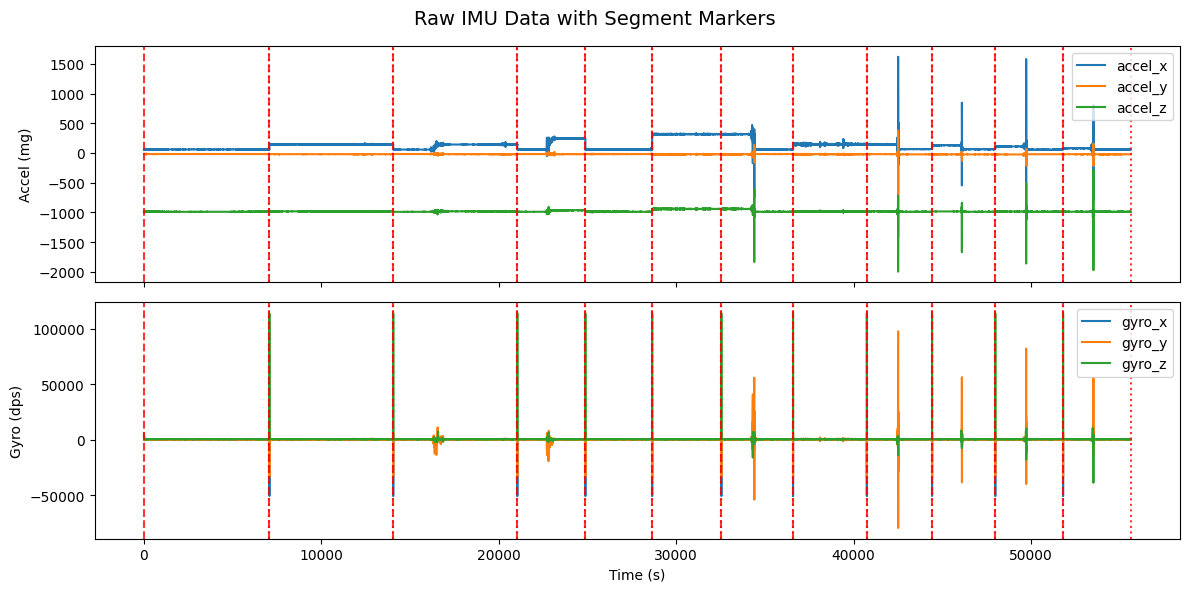


Processing segment 0: Baseline - no movement

Processing segment 1: 5Â° theta rotation (power off)
Test was an off/on test not an on test...

Processing segment 2: 4.7Â° theta rotation (power on)

Processing segment 3: 10.2Â° theta rotation (power on)

Processing segment 4: 10Â° theta return to 0 (power off)
Test was an off/on test not an on test...

Processing segment 5: 15Â° theta rotation (power off)
Test was an off/on test not an on test...

Processing segment 6: 15Â° theta return to 0 (power on)

Processing segment 7: 5Â° theta rotation (power off)
Test was an off/on test not an on test...

Processing segment 8: 5Â° theta return to 0 (power on)

Processing segment 9: 4Â° theta rotation (offâ†’on)
Test was an off/on test not an on test...

Processing segment 10: 3Â° theta rotation (offâ†’on)
Test was an off/on test not an on test...

Processing segment 11: 1.2Â° theta rotation (offâ†’on)
Test was an off/on test not an on test...

Detailed results saved to test_config_altitude_resu

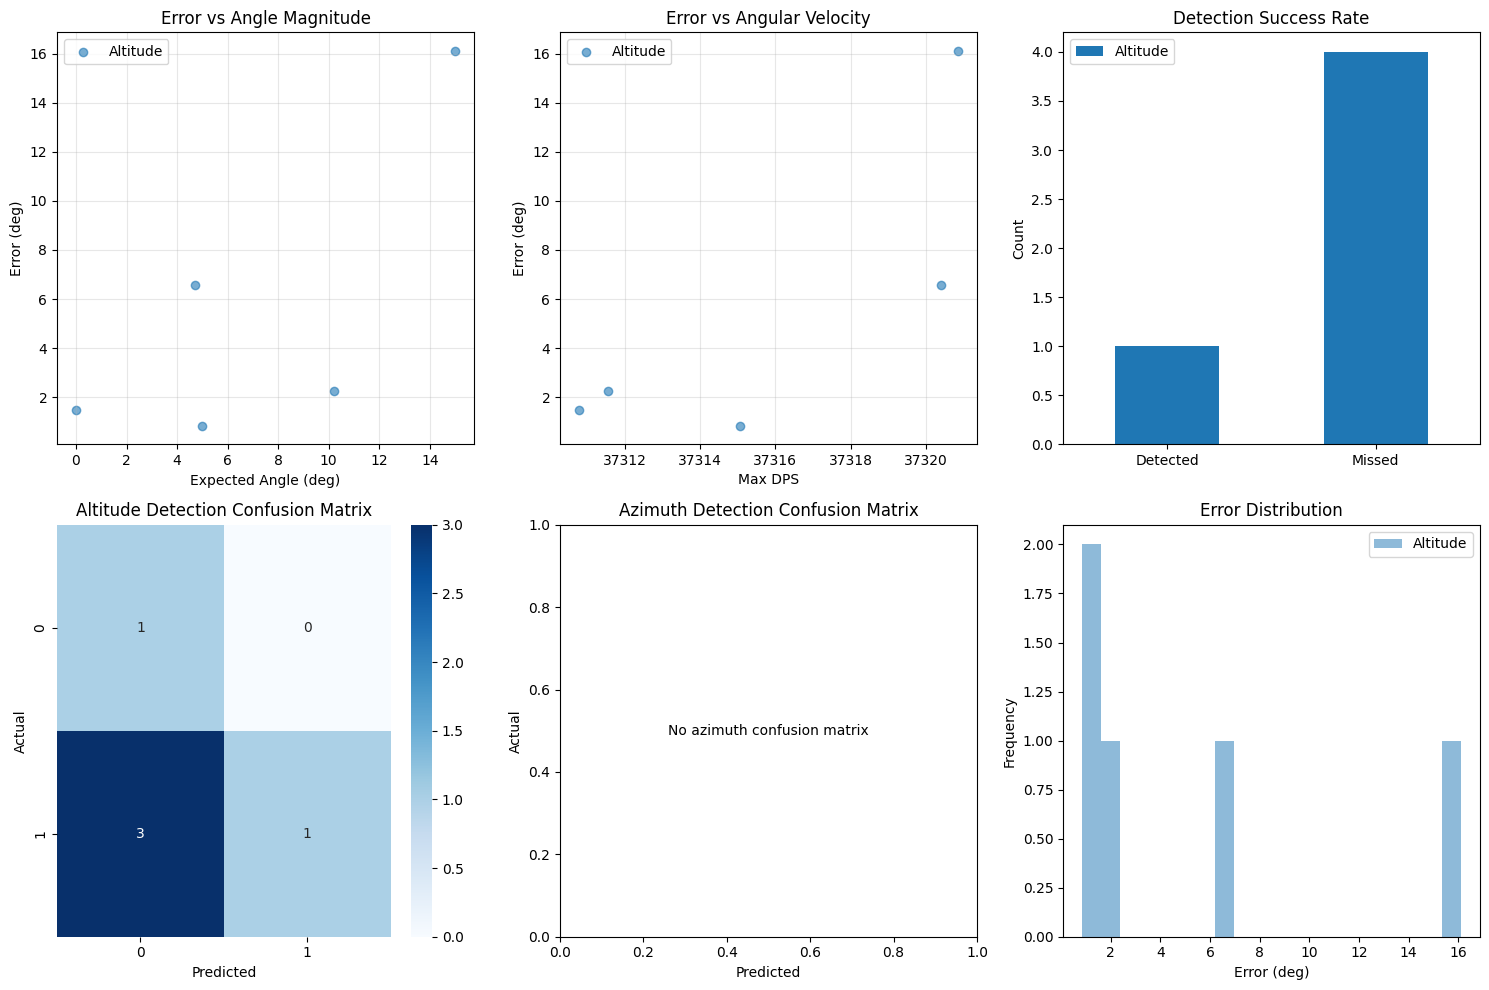

Skipping error heatmap due to: "['expected_phi'] not in index"

Summary saved to test_config_altitude_summary.txt


0

In [50]:
main()